# Faizaan Ali | HW5 | Task 1

---



## Task 1

### Normal CNN Training

In [ ]:
!pip install ucimlrepo tensorflow scikit-learn matplotlib seaborn

import os
import zipfile
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from sklearn.metrics import classification_report, confusion_matrix

In [ ]:
# Download dataset
# Fungi Classification Dataset
!wget https://archive.ics.uci.edu/static/public/773/defungi.zip

# Unzip
with zipfile.ZipFile("defungi.zip", 'r') as zip_ref:
    zip_ref.extractall("defungi_dataset")

print("Dataset extracted.")

dataset_path = "defungi_dataset"

print(os.listdir(dataset_path))

--2026-03-16 18:54:46--  https://archive.ics.uci.edu/static/public/773/defungi.zip
Resolving archive.ics.uci.edu (archive.ics.uci.edu)... 128.195.10.252
Connecting to archive.ics.uci.edu (archive.ics.uci.edu)|128.195.10.252|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: unspecified
Saving to: ‘defungi.zip’

defungi.zip             [                 <=>] 149.10M  45.9MB/s    in 3.4s    

2026-03-16 18:54:50 (43.8 MB/s) - ‘defungi.zip’ saved [156341364]

Dataset extracted.
['H2', 'H5', 'H6', 'H3', 'H1']


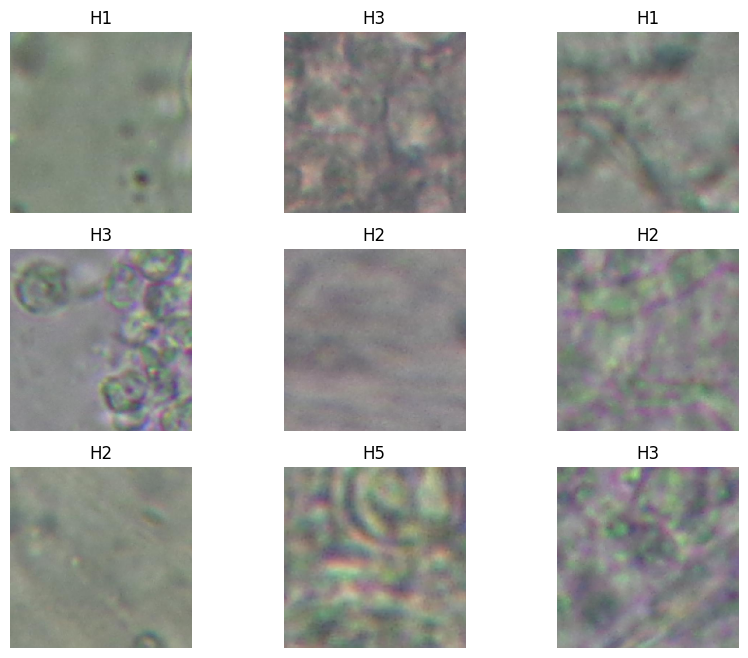

In [ ]:
import random
from tensorflow.keras.preprocessing import image

classes = os.listdir(dataset_path)

plt.figure(figsize=(10,8))

for i in range(9):
    class_name = random.choice(classes)
    img_name = random.choice(os.listdir(os.path.join(dataset_path,class_name)))

    img_path = os.path.join(dataset_path,class_name,img_name)
    img = image.load_img(img_path, target_size=(224,224))

    plt.subplot(3,3,i+1)
    plt.imshow(img)
    plt.title(class_name)
    plt.axis("off")

plt.show()

Loading data into Train/Val split...
We scale the RGB images and create batches of size 32 for training.  

In [ ]:
from sklearn.utils.class_weight import compute_class_weight
import numpy as np

img_size = (224,224)
batch_size = 32

datagen = ImageDataGenerator(
    rescale=1./255,
    validation_split=0.2
)

train_data = datagen.flow_from_directory(
    dataset_path,
    target_size=img_size,
    batch_size=batch_size,
    class_mode='categorical',
    subset='training',
    shuffle=True
)

val_data = datagen.flow_from_directory(
    dataset_path,
    target_size=img_size,
    batch_size=batch_size,
    class_mode='categorical',
    subset='validation',
    shuffle=False
)

class_weights = compute_class_weight(
    class_weight="balanced",
    classes=np.unique(train_data.classes),
    y=train_data.classes
)

class_weights = dict(enumerate(class_weights))

print(class_weights)

Found 7295 images belonging to 5 classes.
Found 1819 images belonging to 5 classes.
{0: np.float64(0.41401816118047674), 1: np.float64(0.7810492505353319), 2: np.float64(2.2240853658536586), 3: np.float64(2.2274809160305344), 4: np.float64(2.464527027027027)}


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 222, 222, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 111, 111, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 109, 109, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 54, 54, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 52, 52, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 26, 26, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 24, 24, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 12, 12, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 256)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │        65,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 5)              │         1,285 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 455,493 (1.74 MB)

 Trainable params: 455,493 (1.74 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/10
228/228 ━━━━━━━━━━━━━━━━━━━━ 34s 113ms/step - accuracy: 0.2318 - loss: 1.4970 - val_accuracy: 0.4750 - val_loss: 1.3750
Epoch 2/10
228/228 ━━━━━━━━━━━━━━━━━━━━ 19s 81ms/step - accuracy: 0.4463 - loss: 1.2383 - val_accuracy: 0.5415 - val_loss: 1.2460
Epoch 3/10
228/228 ━━━━━━━━━━━━━━━━━━━━ 18s 79ms/step - accuracy: 0.5374 - loss: 1.1032 - val_accuracy: 0.5283 - val_loss: 1.2761
Epoch 4/10
228/228 ━━━━━━━━━━━━━━━━━━━━ 17s 73ms/step - accuracy: 0.5666 - loss: 1.0619 - val_accuracy: 0.5734 - val_loss: 1.1502
Epoch 5/10
228/228 ━━━━━━━━━━━━━━━━━━━━ 17s 73ms/step - accuracy: 0.5733 - loss: 1.0508 - val_accuracy: 0.5003 - val_loss: 1.3009
Epoch 6/10
228/228 ━━━━━━━━━━━━━━━━━━━━ 18s 77ms/step - accuracy: 0.5845 - loss: 1.0307 - val_accuracy: 0.5596 - val_loss: 1.1967
Epoch 7/10
228/228 ━━━━━━━━━━━━━━━━━━━━ 16s 72ms/step - accuracy: 0.5888 - loss: 1.0120 - val_accuracy: 0.5965 - val_loss: 1.1084
Epoch 8/10
228/228 ━━━━━━━━━━━━━━━━━━━━ 17s 75ms/step - accuracy: 0.5940 - loss: 0.9922 -

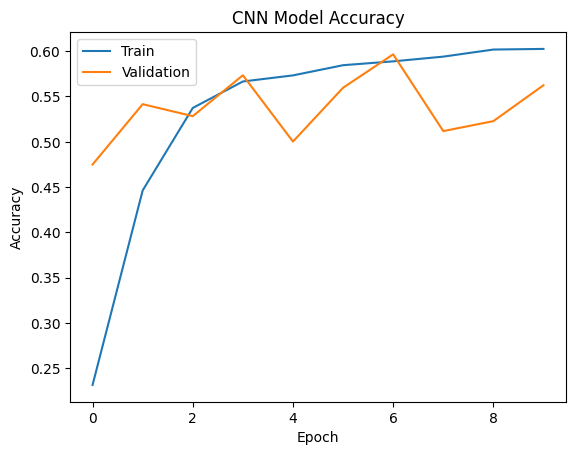

57/57 ━━━━━━━━━━━━━━━━━━━━ 3s 59ms/step - accuracy: 0.5624 - loss: 1.1658
Validation Loss: 1.1657723188400269
Validation Accuracy: 0.5623969435691833
57/57 ━━━━━━━━━━━━━━━━━━━━ 4s 61ms/step


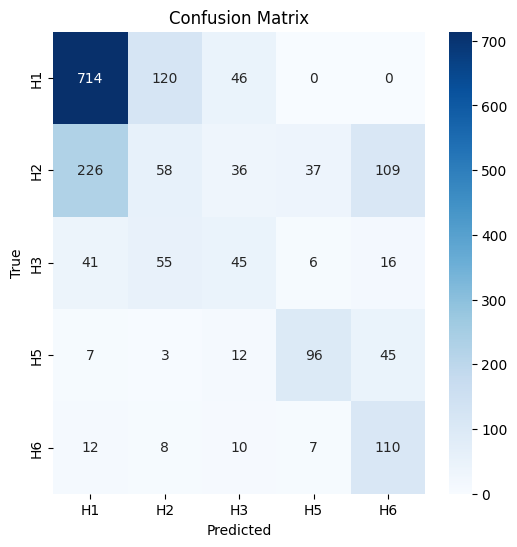

In [ ]:
from tensorflow.keras.optimizers import Adam

model = models.Sequential([

    layers.Conv2D(32, (3,3), activation='relu', input_shape=(224,224,3)),
    layers.MaxPooling2D((2,2)),

    layers.Conv2D(64, (3,3), activation='relu'),
    layers.MaxPooling2D((2,2)),

    layers.Conv2D(128, (3,3), activation='relu'),
    layers.MaxPooling2D((2,2)),

    layers.Conv2D(256, (3,3), activation='relu'),
    layers.MaxPooling2D((2,2)),

    layers.GlobalAveragePooling2D(),

    layers.Dense(256, activation='relu'),
    layers.Dropout(0.5),

    layers.Dense(train_data.num_classes, activation='softmax')
])

# CNN using 4 Conv2D/MaxPooling2D layer pairs and a Dropout layer for regularization
#   Fairly simple CNN (only 4 layers), and Dropout and MaxPooling2D help with overfitting

model.summary()
model.compile(
    optimizer=Adam(learning_rate=1e-4),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)
history = model.fit(
    train_data,
    validation_data=val_data,
    epochs=10,
    class_weight=class_weights
)
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.title("CNN Model Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend(["Train","Validation"])
plt.show()

val_loss, val_acc = model.evaluate(val_data)

print("Validation Loss:", val_loss)
print("Validation Accuracy:", val_acc)

y_pred = model.predict(val_data)
y_pred = np.argmax(y_pred, axis=1)
y_true = val_data.classes
cm = confusion_matrix(y_true, y_pred)

# Plot CM
plt.figure(figsize=(6,6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=val_data.class_indices.keys(),
            yticklabels=val_data.class_indices.keys())
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Confusion Matrix")
plt.show()

The baseline CNN showed steady improvement during training, with training accuracy increasing from approximately 23% in the first epoch to about 60% by the final epoch, while the training loss decreased from 1.49 to 0.98. Validation accuracy fluctuated throughout training but generally remained between 50% and 60%, reaching a peak of about 59.6% in epoch 7 and finishing with a final validation accuracy of 56.2% and validation loss of 1.17. These results indicate that the model was able to learn meaningful visual features from the dataset, though the gap between training and validation performance suggests some degree of variability in generalization. Overall, the baseline CNN achieved moderate performance and provides a useful reference point for evaluating improvements from techniques such as data augmentation or transfer learning.

### Transfer Learning

Found 7295 images belonging to 5 classes.
Found 1819 images belonging to 5 classes.
9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_1       │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Conv1 (Conv2D)      │ (None, 112, 112,  │        864 │ input_layer_1[0]… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bn_Conv1            │ (None, 112, 112,  │        128 │ Conv1[0][0]       │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Conv1_relu (ReLU)   │ (None, 112, 112,  │          0 │ bn_Conv1[0][0]    │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 112, 112,  │        288 │ Conv1_relu[0][0]  │
│ (DepthwiseConv2D)   │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 112, 112,  │        128 │ expanded_conv_de… │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 112, 112,  │          0 │ expanded_conv_de… │
│ (ReLU)              │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_proj… │ (None, 112, 112,  │        512 │ expanded_conv_de… │
│ (Conv2D)            │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_proj… │ (None, 112, 112,  │         64 │ expanded_conv_pr… │
│ (BatchNormalizatio… │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand      │ (None, 112, 112,  │      1,536 │ expanded_conv_pr… │
│ (Conv2D)            │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand_BN   │ (None, 112, 112,  │        384 │ block_1_expand[0… │
│ (BatchNormalizatio… │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand_relu │ (None, 112, 112,  │          0 │ block_1_expand_B… │
│ (ReLU)              │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_pad         │ (None, 113, 113,  │          0 │ block_1_expand_r… │
│ (ZeroPadding2D)     │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise   │ (None, 56, 56,    │        864 │ block_1_pad[0][0] │
│ (DepthwiseConv2D)   │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise_… │ (None, 56, 56,    │        384 │ block_1_depthwis… │
│ (BatchNormalizatio… │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise_… │ (None, 56, 56,    │          0 │ block_1_depthwis… │
│ (ReLU)              │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_project     │ (None, 56, 56,    │      2,304 │ block_1_depthwis

 Total params: 2,592,325 (9.89 MB)

 Trainable params: 1,537,861 (5.87 MB)

 Non-trainable params: 1,054,464 (4.02 MB)

Epoch 1/10
228/228 ━━━━━━━━━━━━━━━━━━━━ 69s 203ms/step - accuracy: 0.5058 - loss: 1.2081 - val_accuracy: 0.5410 - val_loss: 2.4938
Epoch 2/10
228/228 ━━━━━━━━━━━━━━━━━━━━ 16s 72ms/step - accuracy: 0.6762 - loss: 0.6410 - val_accuracy: 0.5344 - val_loss: 1.7369
Epoch 3/10
228/228 ━━━━━━━━━━━━━━━━━━━━ 17s 75ms/step - accuracy: 0.7486 - loss: 0.4702 - val_accuracy: 0.5596 - val_loss: 2.1306
Epoch 4/10
228/228 ━━━━━━━━━━━━━━━━━━━━ 17s 74ms/step - accuracy: 0.7988 - loss: 0.3472 - val_accuracy: 0.4486 - val_loss: 2.0070
Epoch 5/10
228/228 ━━━━━━━━━━━━━━━━━━━━ 16s 72ms/step - accuracy: 0.8380 - loss: 0.2797 - val_accuracy: 0.4986 - val_loss: 2.1165
Epoch 6/10
228/228 ━━━━━━━━━━━━━━━━━━━━ 18s 79ms/step - accuracy: 0.8702 - loss: 0.2162 - val_accuracy: 0.5607 - val_loss: 2.3971
Epoch 7/10
228/228 ━━━━━━━━━━━━━━━━━━━━ 17s 74ms/step - accuracy: 0.9006 - loss: 0.1760 - val_accuracy: 0.5322 - val_loss: 2.3134
Epoch 8/10
228/228 ━━━━━━━━━━━━━━━━━━━━ 17s 73ms/step - accuracy: 0.9136 - loss: 0.1546 -

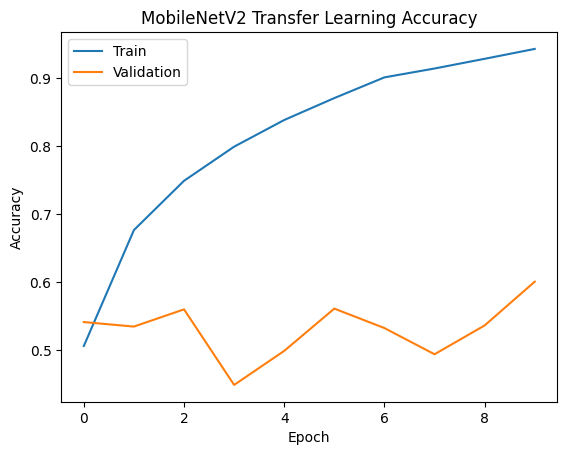

57/57 ━━━━━━━━━━━━━━━━━━━━ 3s 59ms/step - accuracy: 0.6003 - loss: 2.3220
Validation Loss: 2.32196044921875
Validation Accuracy: 0.6003298759460449
57/57 ━━━━━━━━━━━━━━━━━━━━ 11s 127ms/step


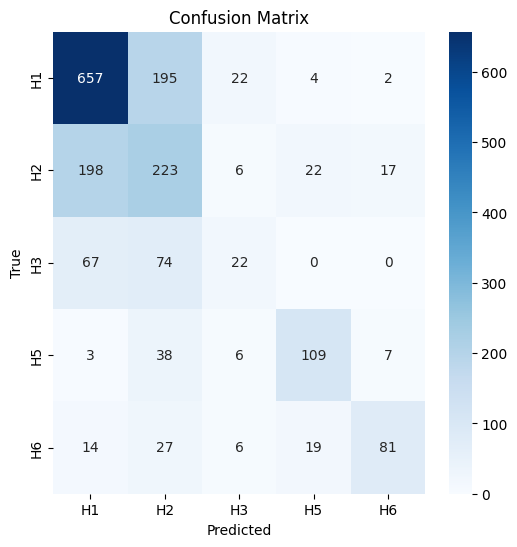

In [ ]:
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.applications.mobilenet_v2 import preprocess_input
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras import layers, models
from tensorflow.keras.optimizers import Adam
import matplotlib.pyplot as plt

datagen = ImageDataGenerator(
    preprocessing_function=preprocess_input,
    validation_split=0.2
)

train_data = datagen.flow_from_directory(
    dataset_path,
    target_size=(224,224),
    batch_size=32,
    class_mode='categorical',
    subset='training',
    shuffle=True
)

val_data = datagen.flow_from_directory(
    dataset_path,
    target_size=(224,224),
    batch_size=32,
    class_mode='categorical',
    subset='validation',
    shuffle=False
)

# Load Pretrained MobileNetV2
base_model = MobileNetV2(
    weights='imagenet',
    include_top=False,
    input_shape=(224,224,3)
)

# Freeze most layers
for layer in base_model.layers[:-20]:
    layer.trainable = False

for layer in base_model.layers[-20:]:
    layer.trainable = True

# Custom Classification Head
x = base_model.output
x = layers.GlobalAveragePooling2D()(x)

x = layers.BatchNormalization()(x)
x = layers.Dense(256, activation='relu')(x)
x = layers.Dropout(0.5)(x)

predictions = layers.Dense(train_data.num_classes, activation='softmax')(x)

transfer_model = models.Model(inputs=base_model.input, outputs=predictions)

# Compile Model
transfer_model.compile(
    optimizer=Adam(learning_rate=1e-4),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

transfer_model.summary()

# Train Model
history_transfer = transfer_model.fit(
    train_data,
    validation_data=val_data,
    epochs=10,
    class_weight=class_weights
)

# Plot
plt.plot(history_transfer.history['accuracy'])
plt.plot(history_transfer.history['val_accuracy'])
plt.title("MobileNetV2 Transfer Learning Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend(["Train","Validation"])
plt.show()

# Eval
val_loss, val_acc = transfer_model.evaluate(val_data)

print("Validation Loss:", val_loss)
print("Validation Accuracy:", val_acc)

y_pred = transfer_model.predict(val_data)
y_pred = np.argmax(y_pred, axis=1)
y_true = val_data.classes
cm = confusion_matrix(y_true, y_pred)

# Plot CM
plt.figure(figsize=(6,6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=val_data.class_indices.keys(),
            yticklabels=val_data.class_indices.keys())
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Confusion Matrix")
plt.show()

The transfer learning model using MobileNetV2 showed significantly stronger learning on the training data compared to the baseline CNN. Training accuracy increased rapidly from approximately 50.6% in the first epoch to 94.2% by epoch 10, while the training loss decreased from 1.21 to 0.11, indicating that the model was able to effectively learn discriminative features using the pretrained architecture. However, validation performance remained relatively stable and fluctuated between 44% and 60%, ultimately reaching a final validation accuracy of 60.0% with a validation loss of 2.32. The large gap between training accuracy and validation performance suggests that the model experienced overfitting, where it learned the training data very well but struggled to generalize to unseen validation samples. Despite this, the transfer learning approach still slightly outperformed the baseline CNN in validation accuracy, showing the benefit of using pretrained feature extractors for image classification tasks, rather than training from scratch.

### Augmenting Data

Found 7295 images belonging to 5 classes.
Found 1819 images belonging to 5 classes.


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_4 (Conv2D)               │ (None, 222, 222, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 111, 111, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 109, 109, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 54, 54, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_6 (Conv2D)               │ (None, 52, 52, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_6 (MaxPooling2D)  │ (None, 26, 26, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, 24, 24, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_7 (MaxPooling2D)  │ (None, 12, 12, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_2      │ (None, 256)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 256)            │        65,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 5)              │         1,285 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 455,493 (1.74 MB)

 Trainable params: 455,493 (1.74 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/10
228/228 ━━━━━━━━━━━━━━━━━━━━ 101s 429ms/step - accuracy: 0.3894 - loss: 1.4016 - val_accuracy: 0.5239 - val_loss: 1.3044
Epoch 2/10
228/228 ━━━━━━━━━━━━━━━━━━━━ 96s 420ms/step - accuracy: 0.5117 - loss: 1.2439 - val_accuracy: 0.5888 - val_loss: 1.1106
Epoch 3/10
228/228 ━━━━━━━━━━━━━━━━━━━━ 95s 416ms/step - accuracy: 0.5400 - loss: 1.1681 - val_accuracy: 0.5679 - val_loss: 1.1674
Epoch 4/10
228/228 ━━━━━━━━━━━━━━━━━━━━ 94s 413ms/step - accuracy: 0.5622 - loss: 1.1022 - val_accuracy: 0.4458 - val_loss: 1.3679
Epoch 5/10
228/228 ━━━━━━━━━━━━━━━━━━━━ 94s 411ms/step - accuracy: 0.5719 - loss: 1.0460 - val_accuracy: 0.5871 - val_loss: 1.0899
Epoch 6/10
228/228 ━━━━━━━━━━━━━━━━━━━━ 94s 412ms/step - accuracy: 0.5894 - loss: 1.0355 - val_accuracy: 0.5866 - val_loss: 1.0815
Epoch 7/10
228/228 ━━━━━━━━━━━━━━━━━━━━ 94s 412ms/step - accuracy: 0.5819 - loss: 1.0400 - val_accuracy: 0.5618 - val_loss: 1.2066
Epoch 8/10
228/228 ━━━━━━━━━━━━━━━━━━━━ 93s 407ms/step - accuracy: 0.5838 - loss: 

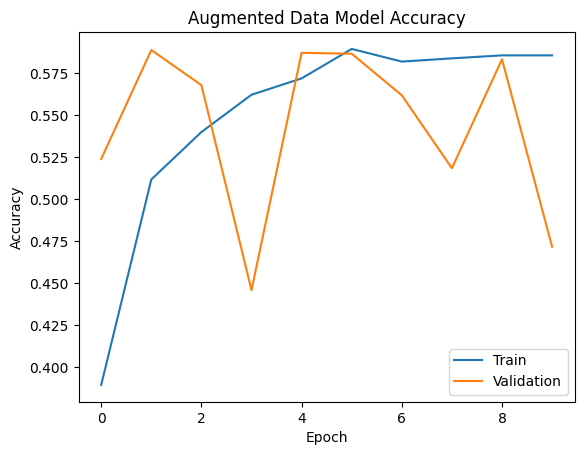

57/57 ━━━━━━━━━━━━━━━━━━━━ 3s 56ms/step - accuracy: 0.4717 - loss: 1.2308
Validation Loss: 1.2307815551757812
Validation Accuracy: 0.4716877341270447
57/57 ━━━━━━━━━━━━━━━━━━━━ 4s 60ms/step


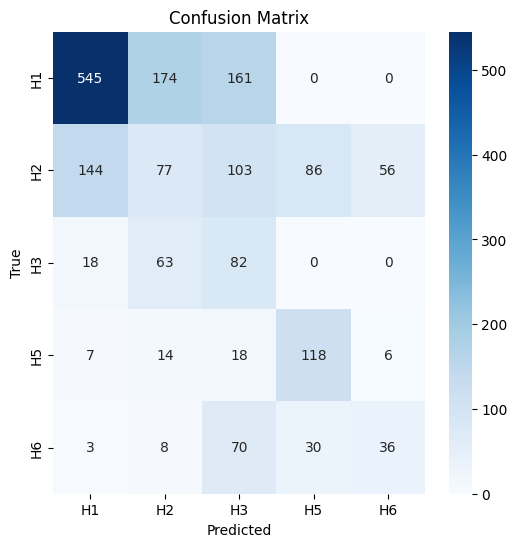

In [ ]:
# Data augmentation generators
train_aug = ImageDataGenerator(
    rescale=1./255,
    rotation_range=30,
    width_shift_range=0.15,
    height_shift_range=0.15,
    zoom_range=0.25,
    shear_range=0.15,
    brightness_range=[0.8,1.2],
    horizontal_flip=True,
    fill_mode='nearest',
    validation_split=0.2
)

val_aug = ImageDataGenerator(
    rescale=1./255,
    validation_split=0.2
)

# Create datasets from generators
train_aug_data = train_aug.flow_from_directory(
    dataset_path,
    target_size=(224,224),
    batch_size=32,
    class_mode='categorical',
    subset='training',
    shuffle=True
)

val_aug_data = val_aug.flow_from_directory(
    dataset_path,
    target_size=(224,224),
    batch_size=32,
    class_mode='categorical',
    subset='validation',
    shuffle=False
)

# CNN model
model = models.Sequential([

    layers.Conv2D(32, (3,3), activation='relu', input_shape=(224,224,3)),
    layers.MaxPooling2D((2,2)),

    layers.Conv2D(64, (3,3), activation='relu'),
    layers.MaxPooling2D((2,2)),

    layers.Conv2D(128, (3,3), activation='relu'),
    layers.MaxPooling2D((2,2)),

    layers.Conv2D(256, (3,3), activation='relu'),
    layers.MaxPooling2D((2,2)),

    layers.GlobalAveragePooling2D(),

    layers.Dense(256, activation='relu'),
    layers.Dropout(0.5),

    layers.Dense(train_aug_data.num_classes, activation='softmax')
])

model.summary()

model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

# Train model
history_aug = model.fit(
    train_aug_data,
    validation_data=val_aug_data,
    epochs=10,
    class_weight=class_weights
)

# Plot results
plt.plot(history_aug.history['accuracy'])
plt.plot(history_aug.history['val_accuracy'])
plt.title("Augmented Data Model Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend(["Train","Validation"])
plt.show()

# Evaluate
val_loss, val_acc = model.evaluate(val_aug_data)

print("Validation Loss:", val_loss)
print("Validation Accuracy:", val_acc)

# Confusion matrix
y_pred = model.predict(val_aug_data)
y_pred = np.argmax(y_pred, axis=1)
y_true = val_aug_data.classes
cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(6,6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=val_aug_data.class_indices.keys(),
            yticklabels=val_aug_data.class_indices.keys())
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Confusion Matrix")
plt.show()

The CNN trained with data augmentation showed moderate improvement in training performance but did not significantly improve validation generalization. Training accuracy increased from 38.9% in the first epoch to about 58.6% by epoch 10, while the training loss gradually decreased from 1.40 to around 1.01, meaning that the model was learning useful features from the augmented images. Validation accuracy initially improved, reaching a peak of 58.9% in epoch 2, but fluctuated throughout training and ultimately dropped to a final validation accuracy of 47.2% with a validation loss of 1.23. This variability suggests that although augmentation introduced greater diversity in the training data, the model struggled to consistently generalize to the validation set. Overall, the augmented model did not outperform the baseline CNN or the transfer learning approach. This probably means that the chosen augmentation strategies (like zooming, shearing, brightening, etc) made the classification task more difficult for the model to learn effectively.